In [69]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping

In [70]:
N = 100 # Gear_Ratio

folder_path = r"S:/Nit Durgapur/College 6th Sem/CSIR-CMERI/Friction_Modelling/EXP_1/EXP_1_Data/12_06_2026"
file = r"J_1_12.06.2026_13_05_36.csv"

file_path = os.path.join(folder_path, file)
df = pd.read_csv(file_path)
print(df.shape)
df.head()

(47265, 25)


,timestamp,m_t_1,m_t_2,m_t_3,m_t_4,m_t_5,m_t_6,jts1,jts2,jts3,...,v3,v4,v5,v6,q1,q2,q3,q4,q5,q6
0,13:05:36.309097,0.01830,-0.00183,-0.0,0.01062,-0.0059,0.02124,0.521055,0.337786,-0.00015,...,0.108,0.006,-0.006,-0.006,0.000687,0.000343,0.006180,0.002747,-0.000000,0.000687
1,13:05:36.314152,0.01830,-0.00183,-0.0,0.01062,-0.0059,0.02124,0.521055,0.337786,-0.00015,...,0.108,0.006,-0.006,-0.006,0.000687,0.000343,0.006180,0.002747,-0.000000,0.000687
2,13:05:36.319315,0.01830,-0.00183,-0.0,0.01062,-0.0059,0.02124,0.521055,0.337786,-0.00015,...,0.108,0.006,-0.006,-0.006,0.000687,0.000343,0.006180,0.002747,-0.000000,0.000687
3,13:05:36.324284,0.01647,-0.00549,-0.0,0.01003,-0.0059,0.02065,0.553648,0.337786,-0.00015,...,-0.054,-0.006,-0.006,-0.018,0.000687,-0.002060,0.006866,-0.000000,0.001373,-0.000687
4,13:05:36.329277,0.01647,-0.00549,-0.0,0.01003,-0.0059,0.02065,0.553648,0.337786,-0.00015,...,-0.054,-0.006,-0.006,-0.018,0.000687,-0.002060,0.006866,-0.000000,0.001373,-0.000687


In [71]:
df["q"] = np.deg2rad(df["q1"])
df["v"] = np.deg2rad(df["v1"])
df["tm"] = df["m_t_1"]
df["tj"] = df["jts1"]

In [72]:
df["tf"] = (N * df["tm"]) - df["tj"]

In [73]:
df["timestamp"] = pd.to_datetime("2026-06-12 " + df["timestamp"].astype(str))

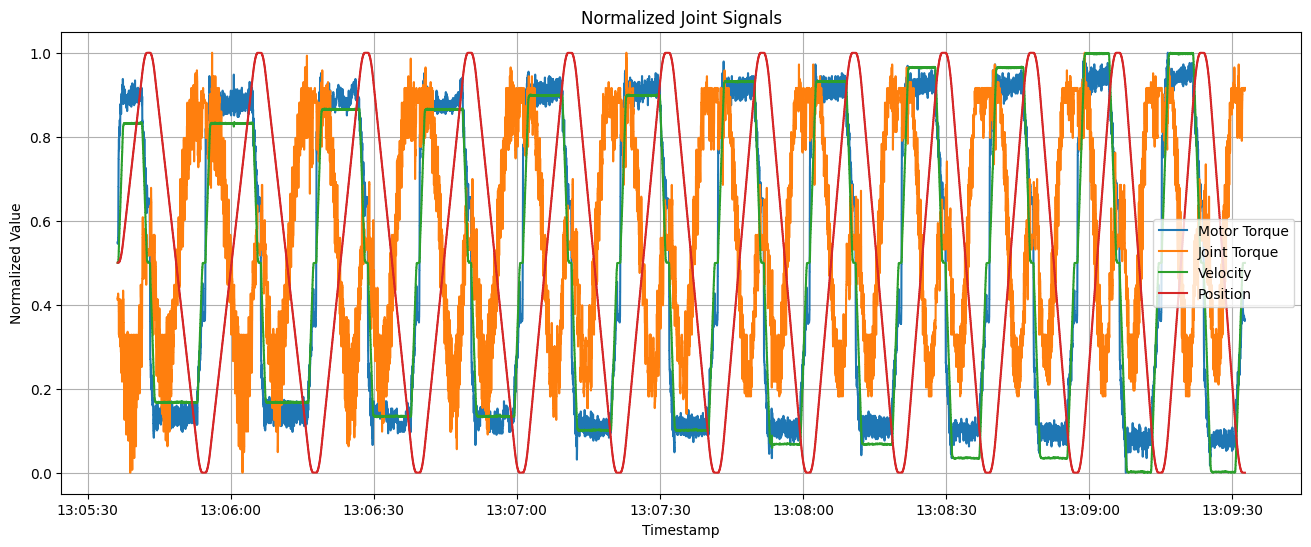

In [74]:
plot_df = df[["tm", "tj", "v", "q"]].copy()
scaler = MinMaxScaler()
plot_scaled = scaler.fit_transform(plot_df)
plot_scaled = pd.DataFrame(
    plot_scaled,
    columns=plot_df.columns
)
plt.figure(figsize=(16,6))
plt.plot(
    df["timestamp"],
    plot_scaled["tm"],
    label="Motor Torque"
)
plt.plot(
    df["timestamp"],
    plot_scaled["tj"],
    label="Joint Torque"
)
plt.plot(
    df["timestamp"],
    plot_scaled["v"],
    label="Velocity"
)
plt.plot(
    df["timestamp"],
    plot_scaled["q"],
    label="Position"
)
plt.legend()
plt.xlabel("Timestamp")
plt.ylabel("Normalized Value")
plt.title("Normalized Joint Signals")
plt.grid(True)
plt.show()

In [75]:
size = len(df)

train_end = int(0.60 * size)
val_end = int(0.80 * size)

train_df = df.iloc[: train_end]
val_df = df.iloc[train_end : val_end]
test_df = df.iloc[val_end :]

print(train_df.shape)
print(val_df.shape)
print(test_df.shape)

(28359, 30)
(9453, 30)
(9453, 30)


In [76]:
def model1(v, Tc, Bv, Vs):
    return (Tc * np.tanh(v/Vs) + Bv * v)

In [77]:
v_train = train_df["v"].values
tf_train = train_df["tf"].values

p0 = [5, 0.1, 0.01]

params1, _ = curve_fit(
    model1,
    v_train,
    tf_train,
    p0 = p0,
    maxfev = 50000
)

Tc1, Bv1, Vs1 = params1

print("Tc =",Tc1)
print("Bv =",Bv1)
print("Vs =",Vs1)

Tc = 9.289417417045312
Bv = 18.728336708150163
Vs = 0.00022643477555494093


In [78]:
v_test = test_df["v"].values
tf_test = test_df["tf"].values

pred1 = model1(v_test, * params1)

In [79]:
rmse1 = np.sqrt(mean_squared_error(tf_test, pred1))
mae1 = mean_absolute_error(tf_test, pred1)
r2_1 = r2_score(tf_test, pred1)

print(rmse1)
print(mae1)
print(r2_1)

2.8042709615232684
2.1404637957491017
0.9798745348987903


In [80]:
def model2(v, Ts, Tc, Bv, Vs, alpha):
    return ((Tc + (Ts-Tc) * np.exp(-(np.abs(v)/Vs) ** alpha)) * np.tanh(v/0.001) + Bv * v)

In [ ]:
p0 = [10, 5, 0.1, 0.05, 1]

params2,_ = curve_fit(
    model2,
    v_train,
    tf_train,
    p0=p0,
    maxfev=100000
)

Ts, Tc, Bv, Vs, alpha = params2

print("Tc = ", Tc)
print("Ts = ", Ts)
print("Bv = ", Bv)
print("Vs = ", Vs)
print("alpha = ", alpha)

C:\Users\HP\AppData\Local\Temp\ipykernel_4580\2944028696.py:2: RuntimeWarning: divide by zero encountered in power
  return ((Tc + (Ts-Tc) * np.exp(-(np.abs(v)/Vs) ** alpha)) * np.tanh(v/0.001) + Bv * v)
C:\Users\HP\AppData\Local\Temp\ipykernel_4580\2944028696.py:2: RuntimeWarning: invalid value encountered in power
  return ((Tc + (Ts-Tc) * np.exp(-(np.abs(v)/Vs) ** alpha)) * np.tanh(v/0.001) + Bv * v)


Tc =  10.099627333072453
Ts =  5808697.444902857
Bv =  -147.20591581120814
Vs =  -147.20591581120814
alpha =  -0.08703111412073662


In [82]:
pred2 = model2(v_test, * params2)

C:\Users\HP\AppData\Local\Temp\ipykernel_4580\2944028696.py:2: RuntimeWarning: divide by zero encountered in power
  return ((Tc + (Ts-Tc) * np.exp(-(np.abs(v)/Vs) ** alpha)) * np.tanh(v/0.001) + Bv * v)


In [83]:
rmse2 = np.sqrt(mean_squared_error(tf_test, pred2))
mae2 = mean_absolute_error(tf_test, pred2)
r2_2 = r2_score(tf_test, pred2)

print(rmse2)
print(mae2)
print(r2_2)

2.901576172971173
2.2879056318926843
0.9784536391690806


In [84]:
pred_train_stribeck = model2(v_train, * params2)

residual_train = (tf_train - pred_train_stribeck)

C:\Users\HP\AppData\Local\Temp\ipykernel_4580\2944028696.py:2: RuntimeWarning: divide by zero encountered in power
  return ((Tc + (Ts-Tc) * np.exp(-(np.abs(v)/Vs) ** alpha)) * np.tanh(v/0.001) + Bv * v)


In [85]:
features = ["q", "v", "tm", "tj"]

X_train = train_df[features].values
X_val = val_df[features].values
X_test = test_df[features].values

In [86]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [87]:
pred_val_stribeck = model2(val_df["v"].values, * params2)

residual_val = (val_df["tf"].values - pred_val_stribeck)

C:\Users\HP\AppData\Local\Temp\ipykernel_4580\2944028696.py:2: RuntimeWarning: divide by zero encountered in power
  return ((Tc + (Ts-Tc) * np.exp(-(np.abs(v)/Vs) ** alpha)) * np.tanh(v/0.001) + Bv * v)


In [88]:
model = Sequential([
    Dense(64, activation='tanh', input_shape=(4,)),
    Dense(64, activation='tanh'),
    Dense(32, activation='tanh'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

c:\Users\HP\.conda\envs\csirinternshipenv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,593 (25.75 KB)

 Trainable params: 6,593 (25.75 KB)

 Non-trainable params: 0 (0.00 B)

In [89]:
early_stop = EarlyStopping(patience = 20, restore_best_weights = True)
history = model.fit(
    X_train,
    residual_train,
    validation_data=(X_val, residual_val),
    epochs=1000,
    batch_size=512,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/1000
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 4.0242 - val_loss: 3.7050
Epoch 2/1000
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 2.8387 - val_loss: 3.6976
Epoch 3/1000
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.6278 - val_loss: 3.5504
Epoch 4/1000
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 2.3648 - val_loss: 3.0159
Epoch 5/1000
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.9469 - val_loss: 2.3163
Epoch 6/1000
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.5400 - val_loss: 1.9942
Epoch 7/1000
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.2608 - val_loss: 1.7127
Epoch 8/1000
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0939 - val_loss: 1.5502
Epoch 9/1000
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9845 - val_loss: 1.3736
Epoch 10/1000
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9237 - val_loss: 1.1418
Epoch 11/1000
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.8672 - val_loss: 1.1570
Epoch 12/1000
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

In [90]:
best_epoch = np.argmin(history.history["val_loss"]) + 1
print("Best Epoch =", best_epoch)
print(
    "Best Validation Loss =",
    np.min(history.history["val_loss"])
)

Best Epoch = 215
Best Validation Loss = 0.04563410207629204


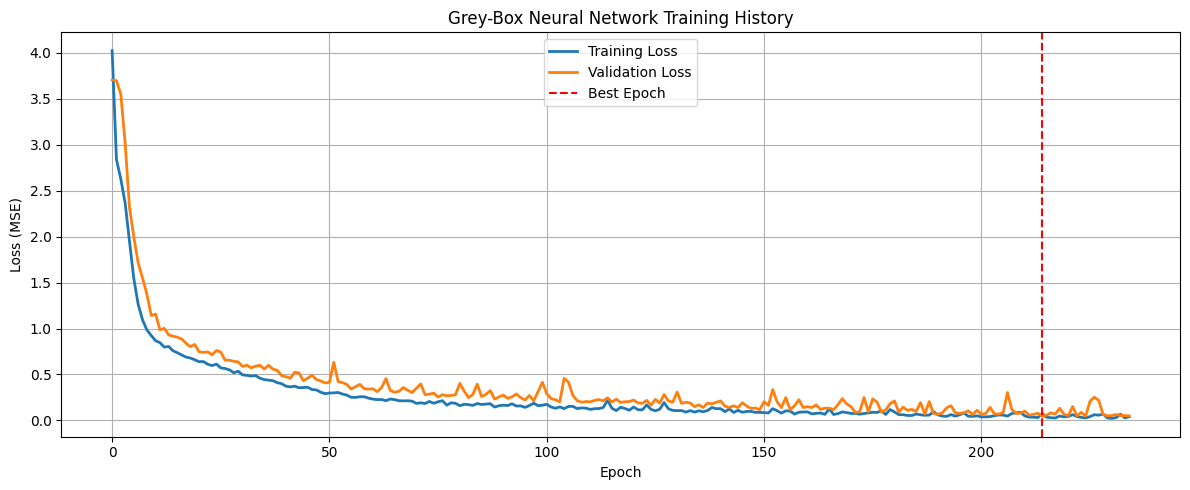

In [91]:
plt.figure(figsize=(12,5))
plt.plot(
    history.history["loss"],
    label="Training Loss",
    linewidth=2
)
plt.plot(
    history.history["val_loss"],
    label="Validation Loss",
    linewidth=2
)
plt.axvline(
    np.argmin(history.history["val_loss"]),
    color='red',
    linestyle='--',
    label='Best Epoch'
)
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.title("Grey-Box Neural Network Training History")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [92]:
nn_residual = model.predict(X_test).flatten()

296/296 ━━━━━━━━━━━━━━━━━━━━ 0s 889us/step


In [93]:
pred3 = (pred2 + nn_residual)

In [94]:
test_time = test_df["timestamp"]

In [95]:
rmse3 = np.sqrt(mean_squared_error(tf_test, pred3))
mae3 = mean_absolute_error(tf_test, pred3)
r2_3 = r2_score(tf_test, pred3)

print(rmse3)
print(mae3)
print(r2_3)

0.3191011135722119
0.24724724901943224
0.9997394070780238


In [96]:
results = pd.DataFrame({
    "Model":[
        "Coulomb + Viscous",
        "Stribeck",
        "GreyBox"
    ],
    "RMSE":[
        rmse1,
        rmse2,
        rmse3
    ],
    "MAE":[
        mae1,
        mae2,
        mae3
    ],
    "R2":[
        r2_1,
        r2_2,
        r2_3
    ]
})

results

,Model,RMSE,MAE,R2
0,Coulomb + Viscous,2.804271,2.140464,0.979875
1,Stribeck,2.901576,2.287906,0.978454
2,GreyBox,0.319101,0.247247,0.999739


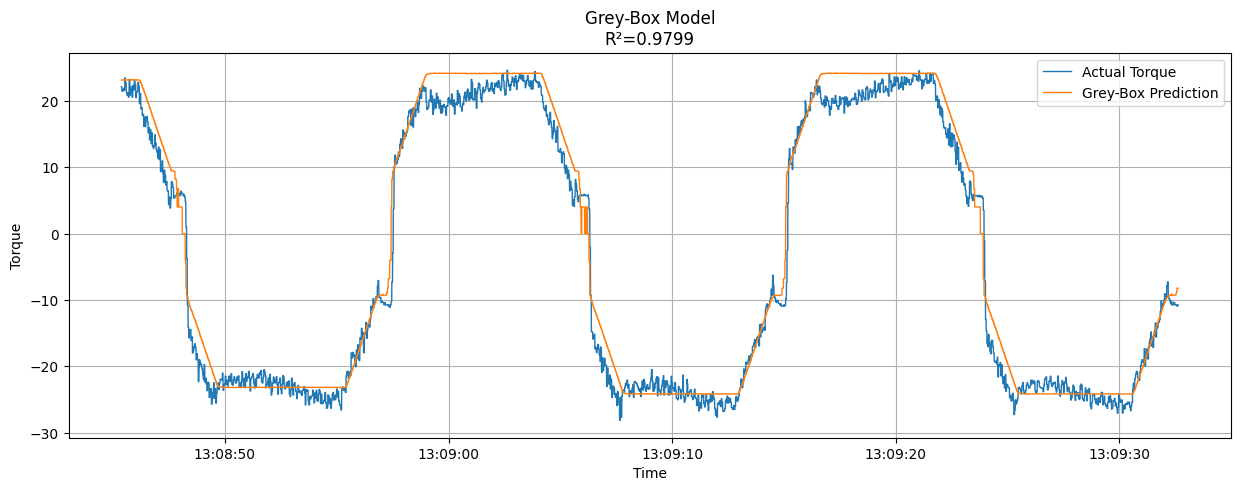

In [97]:
plt.figure(figsize=(15,5))
plt.plot(
    test_time,
    tf_test,
    label="Actual Torque",
    linewidth=1
)
plt.plot(
    test_time,
    pred1,
    label="Grey-Box Prediction",
    linewidth=1
)
plt.xlabel("Time")
plt.ylabel("Torque")
plt.title(f"Grey-Box Model\nR²={r2_1:.4f}")
plt.legend()
plt.grid(True)
plt.show()

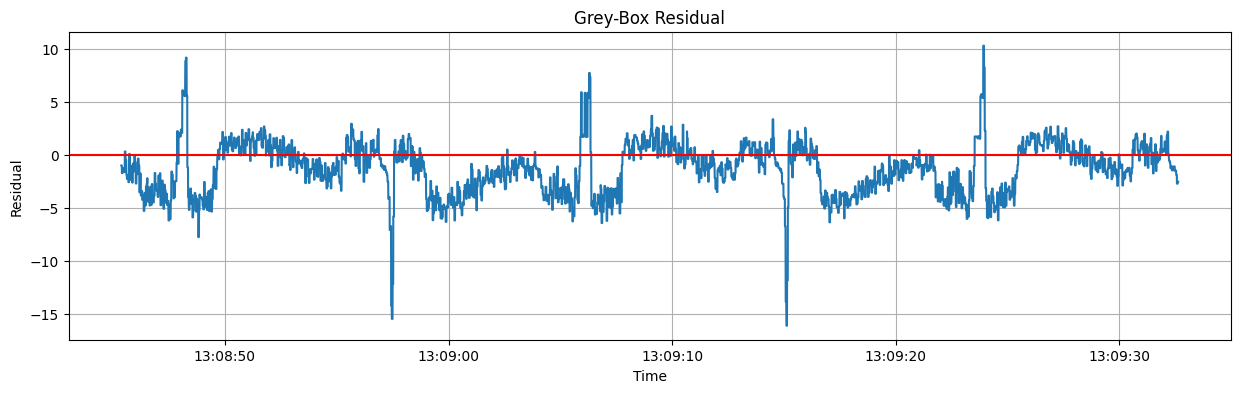

In [98]:
residual1 = tf_test - pred1
plt.figure(figsize=(15,4))
plt.plot(
    test_time,
    residual1
)
plt.axhline(
    0,
    color='red'
)
plt.xlabel("Time")
plt.ylabel("Residual")
plt.title("Grey-Box Residual")
plt.grid(True)
plt.show()

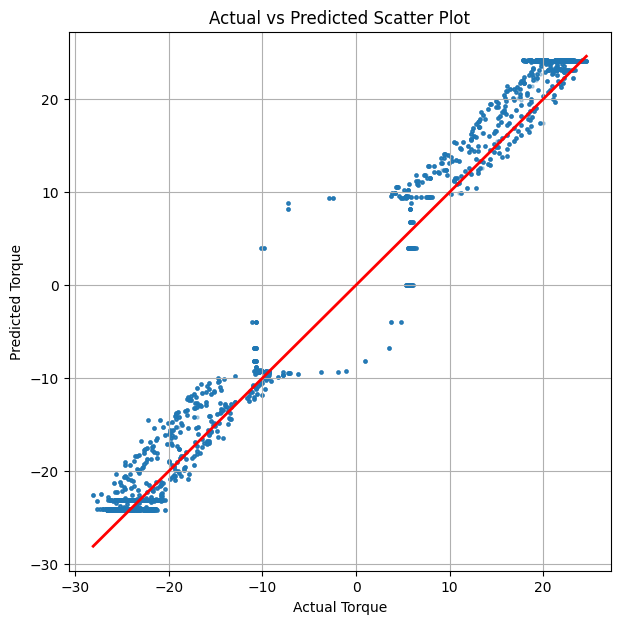

In [99]:
plt.figure(figsize=(7,7))
plt.scatter(
    tf_test, 
    pred1, 
    s=5, 
    alpha=0.3
)
min_val = min(tf_test.min(), pred1.min())
max_val = max(tf_test.max(), pred1.max())
plt.plot(
    [min_val,max_val],
    [min_val,max_val],
    'r', 
    linewidth=2
)
plt.xlabel("Actual Torque")
plt.ylabel("Predicted Torque")
plt.title("Actual vs Predicted Scatter Plot")
plt.grid(True)
plt.show()

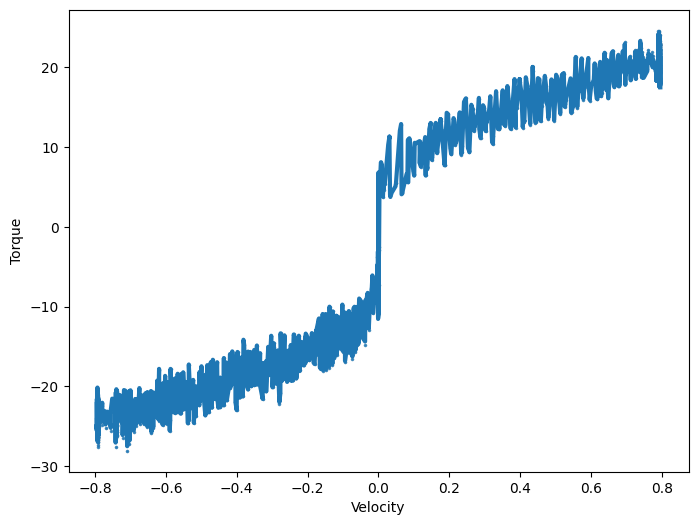

In [100]:
idx = np.argsort(v_test)
plt.figure(figsize=(8,6))
plt.scatter(
    v_test, 
    tf_test, 
    s=2, 
    alpha=0.2
)
plt.plot(
    v_test[idx], 
    pred3[idx], 
    linewidth=3
)
plt.xlabel("Velocity")
plt.ylabel("Torque")
plt.show()